# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1. ...

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [5]:
import requests, re
# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests .get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

class="menu-item	63
menu-item-type-post_type	61
menu-item-object-page	61
<div	47
</div>	44
and	36
<a	29
-->	26
/>	26
of	25
<link	19
<!--	18
0	18
H.	17


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [6]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup .get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests .get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r .text) .lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re .split('\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf .items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

ValueError: The number of FixedLocator locations (16), usually from a call to set_ticks, does not match the number of ticklabels (15).

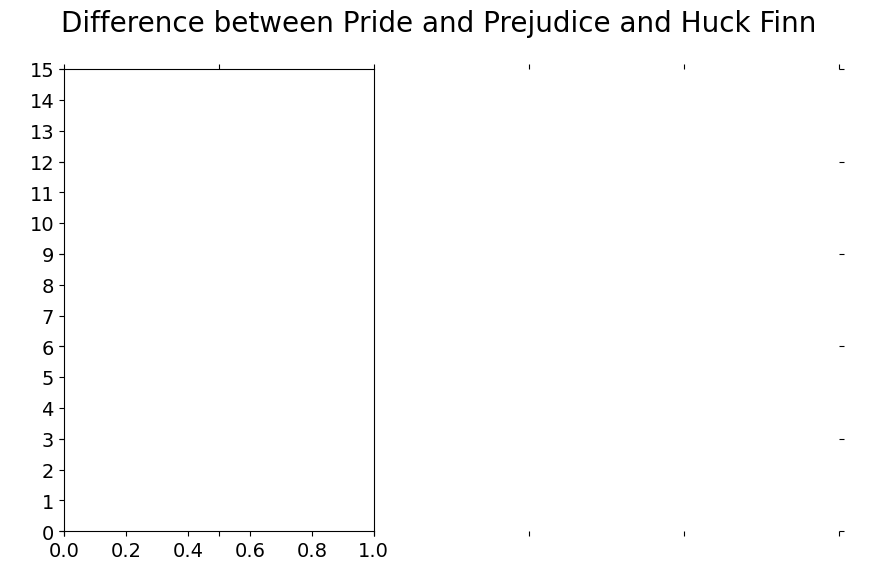

In [7]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee)+1) 
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee ])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu)+1) 
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

In [8]:
#In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
#Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf .items(), key = operator .itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [9]:
import requests, re, nltk
#In case your text is not on Project Gutenberg but at some other URL
#http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests .get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text

In [10]:
len(t)

1323653

# Mini Project 1

## Comparing word frequencies across same and different works

### Research Question

Can word-frequency patterns distinguish between different works by the same author and between works by different authors?

### Sources

1. Pride and Prejudice - Jane Austen
2. Sense and Sensibility - Jane Austen
3. The Adventures of Tom Sawyer - Mark Twain

In [50]:
!pip install requests nltk beautifulsoup4 pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [51]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smazunda/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

print(f"Loaded {len(STOP_WORDS)} English stop words.")

Loaded 198 English stop words.


In [53]:
BOOKS = {
    "Pride and Prejudice": {
        "author": "Jane Austen",
        "url": "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"
    },

    "Sense and Sensibility": {
        "author": "Jane Austen",
        "url": "https://www.gutenberg.org/cache/epub/161/pg161.txt"
    },

    "The Adventures of Tom Sawyer": {
        "author": "Mark Twain",
        "url": "https://www.gutenberg.org/cache/epub/74/pg74.txt"
    }
}

print("Books loaded:")
for title, info in BOOKS.items():
    print(f"- {title} — {info['author']}")

Books loaded:
- Pride and Prejudice — Jane Austen
- Sense and Sensibility — Jane Austen
- The Adventures of Tom Sawyer — Mark Twain


In [54]:
for title, info in BOOKS.items():
    response = requests.get(info["url"])
    
    print(
        f"{title}: "
        f"{len(response.text):,} characters"
    )

Pride and Prejudice: 763,082 characters
Sense and Sensibility: 703,002 characters
The Adventures of Tom Sawyer: 421,360 characters


In [55]:
def clean_text(text):
    # Removes header
    start = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end = "*** END OF THE PROJECT GUTENBERG EBOOK"

    beginning = text.find(start)
    if beginning != -1:
        text = text[text.find("\n", beginning):]

    # Removes footer
    last = text.find(end)
    if last != -1:
        text = text[:last]

    # Convert to lowercase
    text = text.lower()

    # Extract alphabetic words
    words = re.findall(r"\b[a-z]+\b", text)

    # Remove stop words
    words = [word for word in words if word not in STOP_WORDS]

    return words

print("clean_text function is ready!")

clean_text function is ready!


In [56]:
texts = {}
word_lists = {}
frequencies = {}

for title, info in BOOKS.items():
    response = requests.get(info["url"])

    texts[title] = response.text

    # Cleans downloaded text
    word_lists[title] = clean_text(response.text)

    # Count word frequencies
    frequencies[title] = Counter(word_lists[title])

print("Processing complete!\n")

for title in BOOKS:
    print(f"{title}: {len(word_lists[title]):,} words")

Processing complete!

Pride and Prejudice: 57,887 words
Sense and Sensibility: 54,048 words
The Adventures of Tom Sawyer: 34,925 words


In [57]:
for title, freq in frequencies.items():

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

    for word, count in freq.most_common(15):
        print(f"{word:<15} {count}")


Pride and Prejudice
mr              807
elizabeth       645
could           530
would           482
darcy           430
said            406
mrs             353
bennet          339
much            335
miss            315
must            312
bingley         310
jane            302
one             290
know            241

Sense and Sensibility
elinor          684
could           575
marianne        566
mrs             530
would           510
said            397
every           376
one             318
much            290
sister          282
must            279
edward          262
mother          259
dashwood        252
well            240

The Adventures of Tom Sawyer
tom             819
said            355
huck            258
would           238
time            191
one             190
could           179
well            175
got             173
joe             170
boys            158
upon            148
little          143
go              138
see             137


In [58]:
total_words = {}

for title, freq in frequencies.items():
    tw = 0
    
    for word in freq:
        tw += freq[word]
    
    total_words[title] = tw
    
    print(title, ":", tw, "regular words")

Pride and Prejudice : 57887 regular words
Sense and Sensibility : 54048 regular words
The Adventures of Tom Sawyer : 34925 regular words


## Question 1: Comparing two different works by the same author

Compares Jane Austen's Pride and Prejudice and Sense and Sensibility. 
The goal is to determine whether the word-frequency patterns are similar across two different works by the same author.

In [59]:
austen1 = frequencies["Pride and Prejudice"]
austen2 = frequencies["Sense and Sensibility"]

print("Pride and Prejudice:")
print(austen1.most_common(15))

print("\nSense and Sensibility:")
print(austen2.most_common(15))

Pride and Prejudice:
[('mr', 807), ('elizabeth', 645), ('could', 530), ('would', 482), ('darcy', 430), ('said', 406), ('mrs', 353), ('bennet', 339), ('much', 335), ('miss', 315), ('must', 312), ('bingley', 310), ('jane', 302), ('one', 290), ('know', 241)]

Sense and Sensibility:
[('elinor', 684), ('could', 575), ('marianne', 566), ('mrs', 530), ('would', 510), ('said', 397), ('every', 376), ('one', 318), ('much', 290), ('sister', 282), ('must', 279), ('edward', 262), ('mother', 259), ('dashwood', 252), ('well', 240)]


In [60]:
austen_comparison = []

for word in austen1:
    if word in austen2:
        freq1 = austen1[word] / total_words["Pride and Prejudice"]
        freq2 = austen2[word] / total_words["Sense and Sensibility"]
        
        difference = freq1 - freq2
        
        austen_comparison.append((word, difference))

austen_comparison.sort(key=lambda x: abs(x[1]), reverse=True)

for word, difference in austen_comparison[:15]:
    print(word, difference)

mr 0.01064758507016738
jane 0.005198558753169122
edward -0.004830267888961879
dashwood -0.004645247166640979
every -0.003760897527811453
mrs -0.0037080106294758155
john -0.0029652397026799612
thing -0.0028861302153335776
illustration 0.002778826698384819
mother -0.0024253567972504935
colonel -0.0020816622753402807
father 0.0017770676722067165
miss 0.0015562011226564055
heart -0.0015551115245732577
aunt 0.0015017010821894554


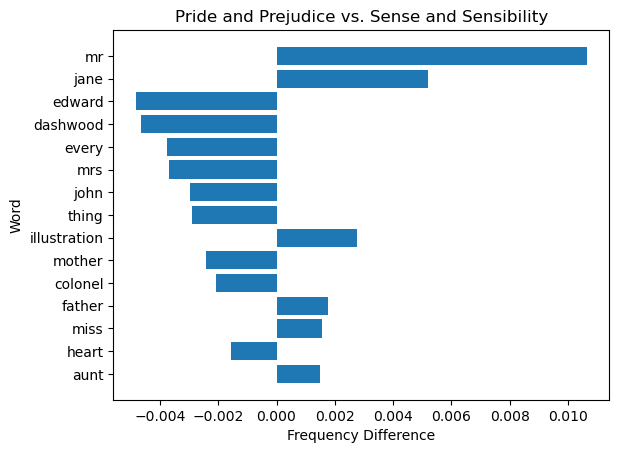

In [71]:
top_words = austen_comparison[:15][::-1]

words = [x[0] for x in top_words]
differences = [x[1] for x in top_words]

plt.barh(words, differences)

plt.xlabel("Frequency Difference")
plt.ylabel("Word")
plt.title("Pride and Prejudice vs. Sense and Sensibility")

plt.show()

### Interpretation

The comparison shows that Jane Austen's two works have both similarities and differences in their word-frequency patterns. 
Although the books were written by the same author, some words occur more frequently in one work than in the other.
This shows that word-frequency analysis can identify similarities and differences between two works by the same author.

In [66]:
total_words = {}

for title, freq in frequencies.items():
    tw = 0
    
    for word in freq:
        tw += freq[word]
    
    total_words[title] = tw
    
    print(title, ":", tw, "regular words")

Pride and Prejudice : 57887 regular words
Sense and Sensibility : 54048 regular words
The Adventures of Tom Sawyer : 34925 regular words


## Question 2: Comparing works by two different authors

Compares Jane Austen's Pride and Prejudice and Mark Twain's The Adventures of Tom Sawyer. 
The goal is to determine whether word-frequency patterns differ between works written by two different authors.

In [67]:
book1 = frequencies["Pride and Prejudice"]
book2 = frequencies["The Adventures of Tom Sawyer"]

different_author_words = set(book1) | set(book2)

author_comparison = []

for word in different_author_words:
    freq1 = book1[word] / total_words["Pride and Prejudice"]
    freq2 = book2[word] / total_words["The Adventures of Tom Sawyer"]
    
    difference = freq1 - freq2
    
    author_comparison.append((word, freq1, freq2, difference))

author_comparison = sorted(
    author_comparison,
    key=lambda x: abs(x[3]),
    reverse=True
)

for item in author_comparison[:20]:
    print(item)

('tom', 0.0, 0.02345025053686471, -0.02345025053686471)
('mr', 0.0139409539274794, 0.0007444523979957051, 0.013196501529483694)
('elizabeth', 0.011142398120476099, 0.0, 0.011142398120476099)
('darcy', 0.007428265413650733, 0.0, 0.007428265413650733)
('huck', 0.0, 0.007387258410880458, -0.007387258410880458)
('bennet', 0.00585623715169209, 0.0, 0.00585623715169209)
('mrs', 0.006098087653531881, 0.0007158196134574087, 0.005382268040074472)
('bingley', 0.005355261112166808, 0.0, 0.005355261112166808)
('miss', 0.005441636291395304, 0.00020042949176807444, 0.00524120679962723)
('jane', 0.005217060825401213, 0.0, 0.005217060825401213)
('joe', 0.0, 0.00486757337151038, -0.00486757337151038)
('got', 0.0004318758961424845, 0.004953471725125268, -0.004521595828982783)
('boys', 5.182510753709814e-05, 0.004523979957050823, -0.004472154849513725)
('must', 0.005389811183858207, 0.0012025769506084467, 0.00418723423324976)
('could', 0.009155768998220671, 0.005125268432355046, 0.0040305005658656246)
('

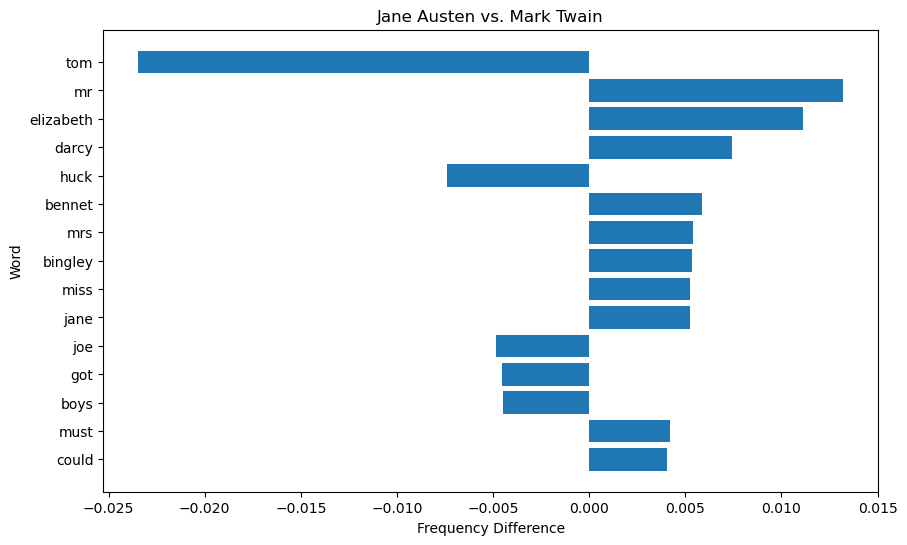

In [70]:
top_words = author_comparison[:15][::-1]

words = [x[0] for x in top_words]
differences = [x[3] for x in top_words]

plt.figure(figsize=(10, 6))

plt.barh(words, differences)

plt.xlabel("Frequency Difference")
plt.ylabel("Word")
plt.title("Jane Austen vs. Mark Twain")

plt.show()

### Interpretation

The comparison shows differences in the frequencies of several words. Because the texts have different lengths, frequency provides a more useful comparison than raw word counts.
The results show that word-frequency patterns can differ between works written by different authors.

## Are there some words preferred by one author but used less frequently by another author?

In [69]:
print("Words relatively more frequent in Jane Austen's book:")
print()

austen_preferred = sorted(
    author_comparison,
    key=lambda x: x[3],
    reverse=True
)

for item in austen_preferred[:15]:
    print(item[0], item[3])

print("\nWords relatively more frequent in Mark Twain's book:")
print()

twain_preferred = sorted(
    author_comparison,
    key=lambda x: x[3]
)

for item in twain_preferred[:15]:
    print(item[0], item[3])

Words relatively more frequent in Jane Austen's book:

mr 0.013196501529483694
elizabeth 0.011142398120476099
darcy 0.007428265413650733
bennet 0.00585623715169209
mrs 0.005382268040074472
bingley 0.005355261112166808
miss 0.00524120679962723
jane 0.005217060825401213
must 0.00418723423324976
could 0.0040305005658656246
much 0.003954638797858325
sister 0.0037027749581327696
though 0.003567435625048822
wickham 0.003455007169139876
collins 0.0032822568106828823

Words relatively more frequent in Mark Twain's book:

tom -0.02345025053686471
huck -0.007387258410880458
joe -0.00486757337151038
got -0.004521595828982783
boys -0.004472154849513725
boy -0.003813600805132909
becky -0.00329277022190408
said -0.0031509739577412566
upon -0.0030111245666232037
back -0.00265855753153909
old -0.002529612311221852
around -0.0024851349676786798
get -0.0023199277530054204
presently -0.0022960632246032025
sid -0.0022619899785254116


### Question 3: Words Preferred by One Author

The results show that some words are relatively more frequent in one author's selected work than in the other author's selected work. In Jane Austen's Pride and Prejudice, words such as "mr", "elizabeth", "darcy", "bennet", and "bingley" have much higher frequencies. In Mark Twain's The Adventures of Tom Sawyer, words such as "tom", "huck", "joe", "boys", and "becky" are relatively more frequent.

Looks like the word "tom" has the largest difference, with a frequency difference of approximately -0.02345. This means that the word appears much more frequently relative to the size of the text in The Adventures of Tom Sawyer than in Pride and Prejudice.

In conclusion, these results absolutely support the idea that word-frequency patterns can reveal differences between authors and their works.

## EXTRA CREDIT ATTEMPT

In [35]:
word = "would"

n1 = total_words["Pride and Prejudice"]
n2 = total_words["Sense and Sensibility"]

x1 = frequencies["Pride and Prejudice"][word]
x2 = frequencies["Sense and Sensibility"][word]

p1 = x1 / n1
p2 = x2 / n2

print("Pride and Prejudice")
print("n =", n1)
print("x =", x1)
print("p =", p1)

print("\nSense and Sensibility")
print("n =", n2)
print("x =", x2)
print("p =", p2)

Pride and Prejudice
n = 57887
x = 482
p = 0.008326567277627102

Sense and Sensibility
n = 54048
x = 510
p = 0.009436056838365897


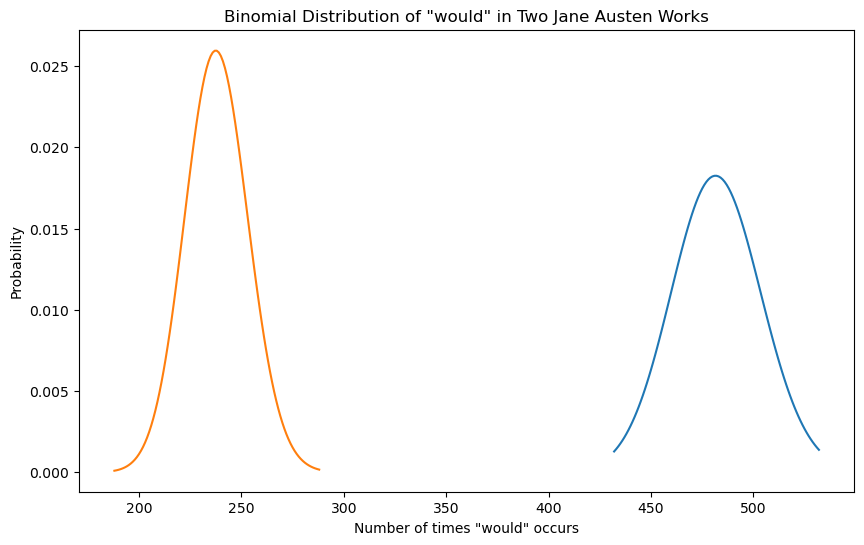

In [75]:
# Sets the range of possible counts around the observed values
x1_values = range(max(0, x1 - 50), x1 + 51)
x2_values = range(max(0, x2 - 50), x2 + 51)

# Calculates binomial probabilities
y1 = binom.pmf(list(x1_values), n1, p1)
y2 = binom.pmf(list(x2_values), n2, p2)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    list(x1_values),
    y1,
    label="Pride and Prejudice"
)

plt.plot(
    list(x2_values),
    y2,
    label="Sense and Sensibility"
)

plt.xlabel('Number of times "would" occurs')
plt.ylabel("Probability")
plt.title('Binomial Distribution of "would" in Two Jane Austen Works')

plt.show()

In [86]:
# Calculate combined probability
comb_p = (x1 + x2) / (n1 + n2)

# Calculate standard error
std_error = sqrt(
    comb_p * (1 - comb_p) *
    (1/n1 + 1/n2)
)

# Calculate z-score
z = (p1 - p2) / std_error

# difference and z-score
print("Difference in probability:", p1 - p2)
print("Z-score:", z)

Difference in probability: 0.001511964557512571
Z-score: 2.5434617138231306


In [87]:
n1 = total_words["Pride and Prejudice"]
n2 = total_words["The Adventures of Tom Sawyer"]

x1 = frequencies["Pride and Prejudice"]["would"]
x2 = frequencies["The Adventures of Tom Sawyer"]["would"]

p1 = x1 / n1
p2 = x2 / n2

print("Pride and Prejudice")
print("Count:", x1)
print("Total:", n1)
print("p:", p1)

print("\nThe Adventures of Tom Sawyer")
print("Count:", x2)
print("Total:", n2)
print("p:", p2)

Pride and Prejudice
Count: 482
Total: 57887
p: 0.008326567277627102

The Adventures of Tom Sawyer
Count: 238
Total: 34925
p: 0.006814602720114531


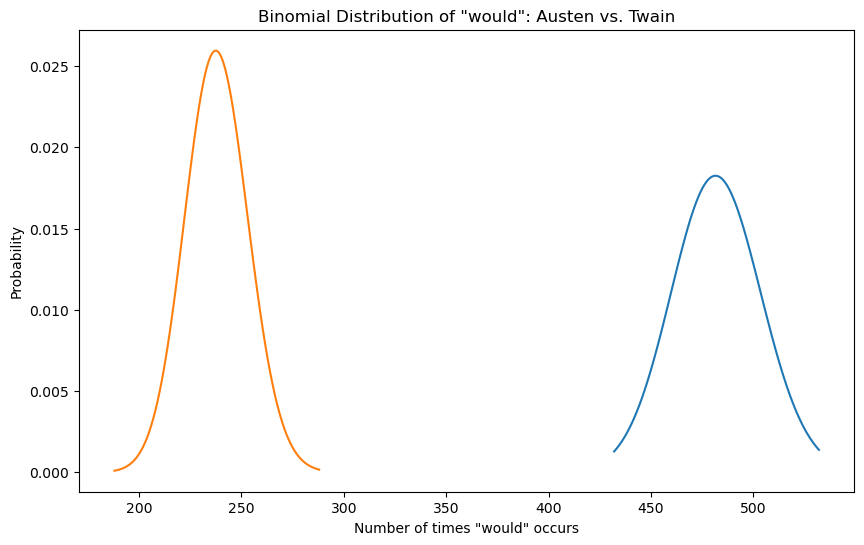

In [88]:
x1_values = range(max(0, x1 - 50), x1 + 51)
x2_values = range(max(0, x2 - 50), x2 + 51)

y1 = binom.pmf(list(x1_values), n1, p1)
y2 = binom.pmf(list(x2_values), n2, p2)

plt.figure(figsize=(10, 6))

plt.plot(
    list(x1_values),
    y1,
    label="Pride and Prejudice"
)

plt.plot(
    list(x2_values),
    y2,
    label="The Adventures of Tom Sawyer"
)

plt.xlabel('Number of times "would" occurs')
plt.ylabel("Probability")
plt.title('Binomial Distribution of "would": Austen vs. Twain')

plt.show()

In [89]:
comb_p = (x1 + x2) / (n1 + n2)

std_error = sqrt(
    comb_p * (1 - comb_p) *
    (1/n1 + 1/n2)
)

z = (p1 - p2) / std_error

print("Difference in probability:", p1 - p2)
print("Z-score:", z)

Difference in probability: 0.001511964557512571
Z-score: 2.5434617138231306


## Extra Credit: Binomial Distribution

Each regular word in a book was treated as a trial, and the probability of "would" was estimated as the number of occurrences divided by the total number of regular words.

For Pride and Prejudice, the estimated probability of "would" was approximately 0.00833. While for Sense and Sensibility, the estimated probability was approximately 0.0094. The difference was statistically significant at the 5% level.

The estimated probability of "would" was approximately 0.00833 in Pride and Prejudice and 0.00681 in The Adventures of Tom Sawyer. These results suggest that the frequency of a specific word can differ significantly between the selected texts.